In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [10]:
import os

print("Carpeta actual:")
print(os.getcwd())

print("\nArchivos del proyecto:")
print(os.listdir("."))

print("\nContenido de datos:")
print(os.listdir("datos"))

Carpeta actual:
/home/rosa/proyecto-datos

Archivos del proyecto:
['.git', 'rosa', 'proyecto-datos', '.ipynb_checkpoints']

Contenido de datos:


FileNotFoundError: [Errno 2] No such file or directory: 'datos'

In [11]:
import os

print(os.listdir("proyecto-datos"))

['.ipynb_checkpoints', 'analisis_heart.ipynb', 'datos']


In [12]:
print(os.listdir("proyecto-datos/datos"))

['heart_disease.csv', '.ipynb_checkpoints']


In [15]:
df = pd.read_csv(
    "proyecto-datos/datos/heart_disease.csv",
    na_values=["?"]
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,2,107,196.0,1.0,0.0,159.0,0.0,1.8,2.0,0.0,NaN,0
1,66,1,2,112,240.0,NaN,0.0,148.0,0.0,0.7,2.0,0.0,NaN,0
2,60,0,2,123,209.0,0.0,0.0,114.0,0.0,1.1,2.0,1.0,3.0,1
3,49,0,3,105,167.0,0.0,0.0,142.0,0.0,0.1,1.0,1.0,3.0,0
4,49,1,2,114,261.0,0.0,0.0,188.0,1.0,0.1,3.0,0.0,7.0,1


In [16]:
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   int64  
 2   cp        5000 non-null   int64  
 3   trestbps  5000 non-null   int64  
 4   chol      4869 non-null   float64
 5   fbs       4925 non-null   float64
 6   restecg   4948 non-null   float64
 7   thalach   4919 non-null   float64
 8   exang     4980 non-null   float64
 9   oldpeak   5000 non-null   float64
 10  slope     4367 non-null   float64
 11  ca        4144 non-null   float64
 12  thal      4406 non-null   float64
 13  num       5000 non-null   int64  
dtypes: float64(9), int64(5)
memory usage: 547.0 KB


In [14]:
df = pd.read_csv(
    "datos/heart_disease.csv",
    na_values=["?"]
)

FileNotFoundError: [Errno 2] No such file or directory: 'datos/heart_disease.csv'

In [6]:
print("Filas y columnas:", df.shape)

display(df.head())
display(df.tail())

df.info()

NameError: name 'df' is not defined

In [17]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,52.432600,14.464595,28.0,40.0,52.0,65.0,77.0
sex,5000.0,0.734200,0.441802,0.0,0.0,1.0,1.0,1.0
cp,5000.0,2.703800,1.028337,1.0,2.0,3.0,4.0,4.0
trestbps,5000.0,119.929600,16.476837,90.0,108.0,120.0,131.0,178.0
chol,4869.0,219.210516,40.292881,120.0,192.0,220.0,246.0,344.0
fbs,4925.0,0.172589,0.377930,0.0,0.0,0.0,0.0,1.0
restecg,4948.0,0.233428,0.461887,0.0,0.0,0.0,0.0,2.0
thalach,4919.0,150.453344,19.434727,81.0,137.0,150.0,164.0,210.0
exang,4980.0,0.310442,0.462721,0.0,0.0,0.0,1.0,1.0
oldpeak,5000.0,0.960600,0.706971,0.0,0.4,0.9,1.4,5.0


In [18]:
faltantes = df.isnull().sum().sort_values(ascending=False)

resumen_faltantes = pd.DataFrame({
    "cantidad_faltante": faltantes,
    "porcentaje": (faltantes / len(df) * 100).round(2)
})

resumen_faltantes

,cantidad_faltante,porcentaje
ca,856,17.12
slope,633,12.66
thal,594,11.88
chol,131,2.62
thalach,81,1.62
fbs,75,1.50
restecg,52,1.04
exang,20,0.40
age,0,0.00
sex,0,0.00


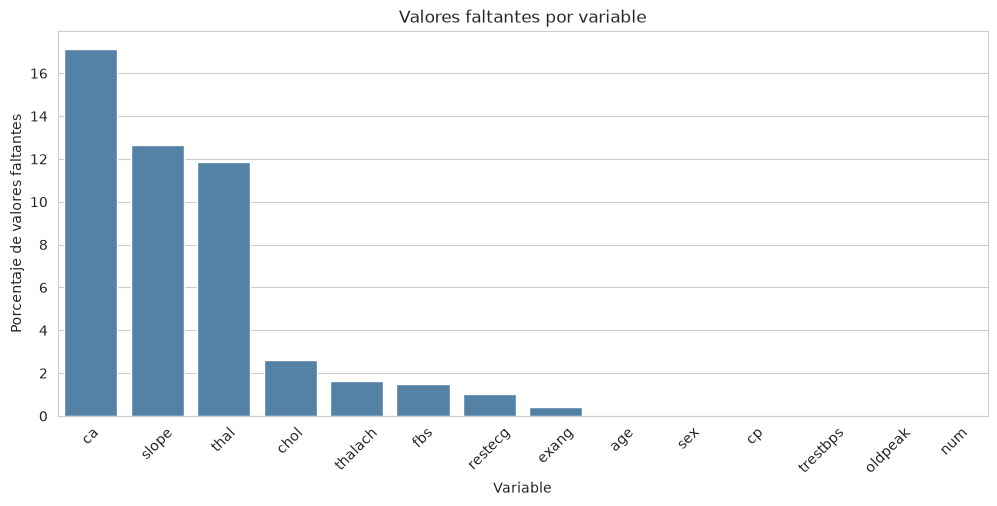

In [19]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=resumen_faltantes.index,
    y=resumen_faltantes["porcentaje"],
    color="steelblue"
)

plt.xticks(rotation=45)
plt.ylabel("Porcentaje de valores faltantes")
plt.xlabel("Variable")
plt.title("Valores faltantes por variable")
plt.show()

In [20]:
print("Registros duplicados:", df.duplicated().sum())

Registros duplicados: 0


In [21]:
df = df.drop_duplicates().reset_index(drop=True)

print("Tamaño después de eliminar duplicados:", df.shape)

Tamaño después de eliminar duplicados: (5000, 14)


In [22]:
for columna in df.columns:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   int64  
 2   cp        5000 non-null   int64  
 3   trestbps  5000 non-null   int64  
 4   chol      4869 non-null   float64
 5   fbs       4925 non-null   float64
 6   restecg   4948 non-null   float64
 7   thalach   4919 non-null   float64
 8   exang     4980 non-null   float64
 9   oldpeak   5000 non-null   float64
 10  slope     4367 non-null   float64
 11  ca        4144 non-null   float64
 12  thal      4406 non-null   float64
 13  num       5000 non-null   int64  
dtypes: float64(9), int64(5)
memory usage: 547.0 KB


In [23]:
print(df["num"].value_counts())
print(df["num"].value_counts(normalize=True).mul(100).round(2))

num
0    2719
1    2281
Name: count, dtype: int64
num
0    54.38
1    45.62
Name: proportion, dtype: float64


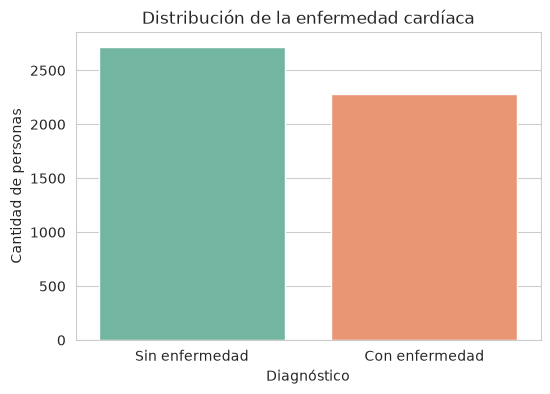

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="num", hue="num", palette="Set2", legend=False)

plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de personas")
plt.title("Distribución de la enfermedad cardíaca")
plt.xticks([0, 1], ["Sin enfermedad", "Con enfermedad"])
plt.show()

In [25]:
columnas_numericas = df.columns.drop("num")

for columna in columnas_numericas:
    df[columna] = df[columna].fillna(df[columna].median())

print("Valores faltantes después de la limpieza:")
print(df.isnull().sum().sum())

Valores faltantes después de la limpieza:
0


In [26]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

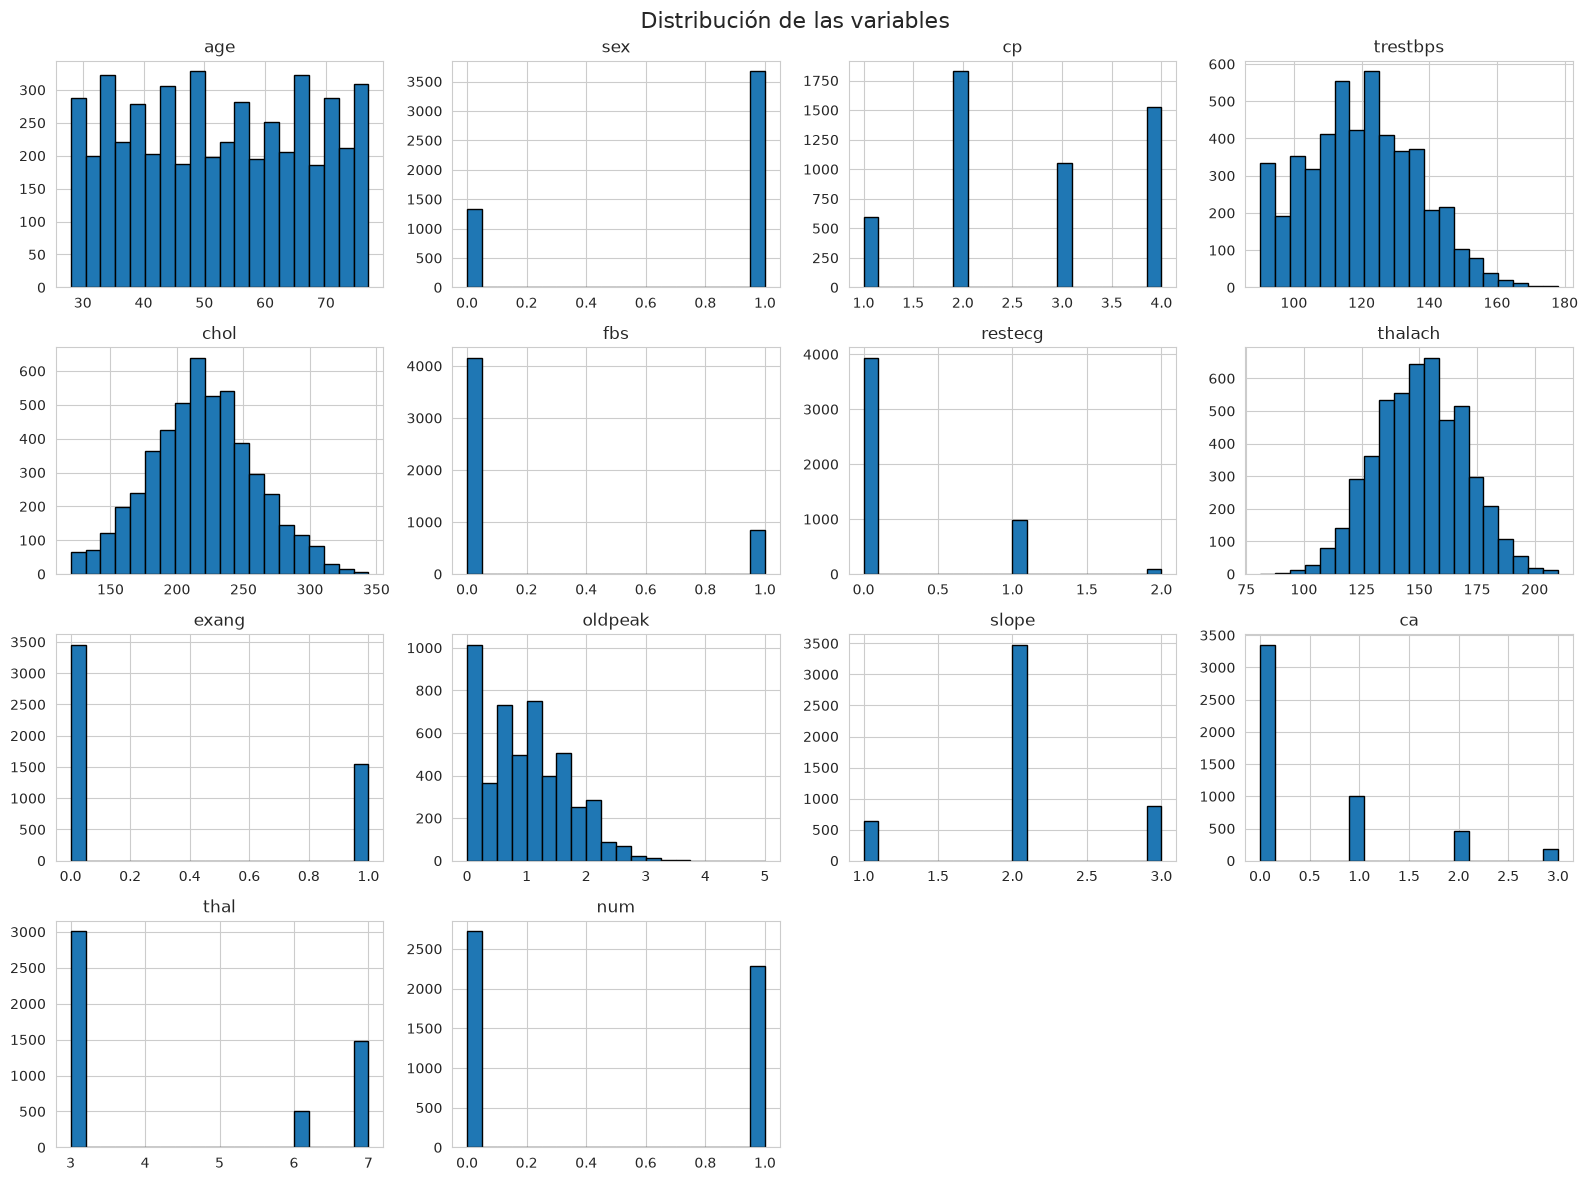

In [27]:
df.hist(
    figsize=(16, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribución de las variables", fontsize=16)
plt.tight_layout()
plt.show()

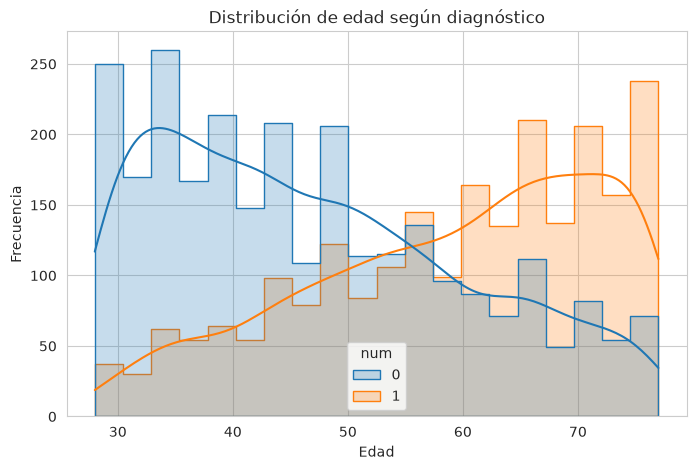

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="num",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Distribución de edad según diagnóstico")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

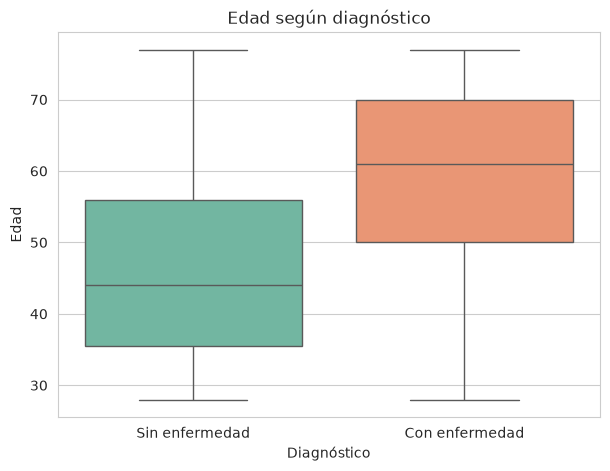

In [29]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="num",
    y="age",
    hue="num",
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Sin enfermedad", "Con enfermedad"])
plt.xlabel("Diagnóstico")
plt.ylabel("Edad")
plt.title("Edad según diagnóstico")
plt.show()

/tmp/ipykernel_7987/2832883677.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Sin enfermedad", "Con enfermedad"])
/tmp/ipykernel_7987/2832883677.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Sin enfermedad", "Con enfermedad"])


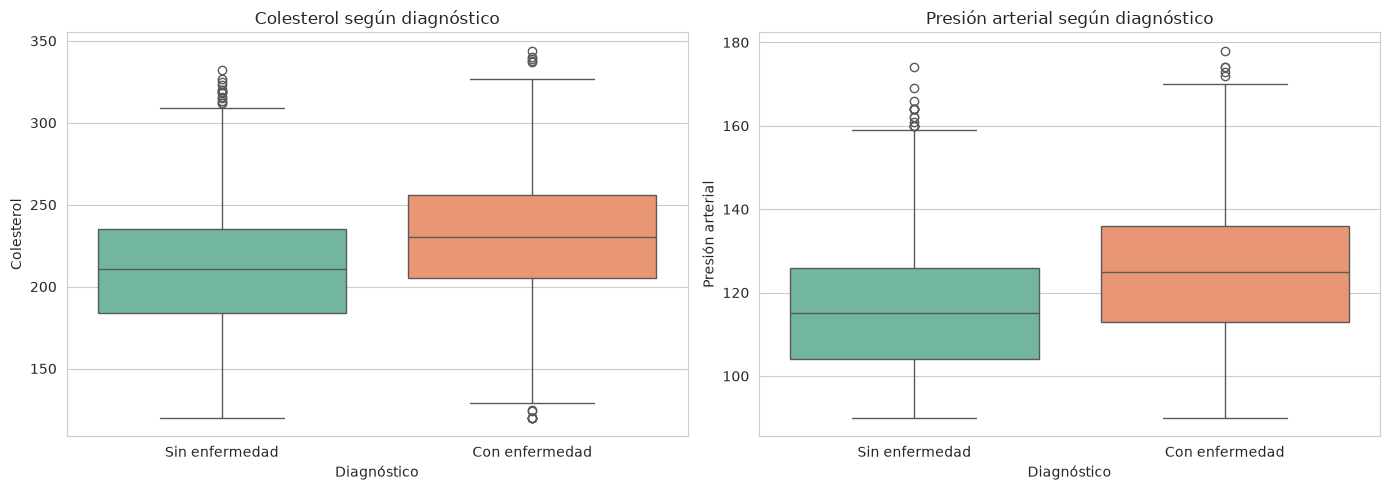

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="num",
    y="chol",
    hue="num",
    ax=axes[0],
    palette="Set2",
    legend=False
)

axes[0].set_title("Colesterol según diagnóstico")
axes[0].set_xlabel("Diagnóstico")
axes[0].set_ylabel("Colesterol")
axes[0].set_xticklabels(["Sin enfermedad", "Con enfermedad"])

sns.boxplot(
    data=df,
    x="num",
    y="trestbps",
    hue="num",
    ax=axes[1],
    palette="Set2",
    legend=False
)

axes[1].set_title("Presión arterial según diagnóstico")
axes[1].set_xlabel("Diagnóstico")
axes[1].set_ylabel("Presión arterial")
axes[1].set_xticklabels(["Sin enfermedad", "Con enfermedad"])

plt.tight_layout()
plt.show()

In [31]:
tabla_cp = pd.crosstab(
    df["cp"],
    df["num"],
    normalize="index"
) * 100

tabla_cp

num,0,1
cp,,
1,60.472973,39.527027
2,59.551177,40.448823
3,55.375833,44.624167
4,45.163399,54.836601


In [32]:
tabla_cp = pd.crosstab(
    df["cp"],
    df["num"],
    normalize="index"
) * 100

tabla_cp

num,0,1
cp,,
1,60.472973,39.527027
2,59.551177,40.448823
3,55.375833,44.624167
4,45.163399,54.836601


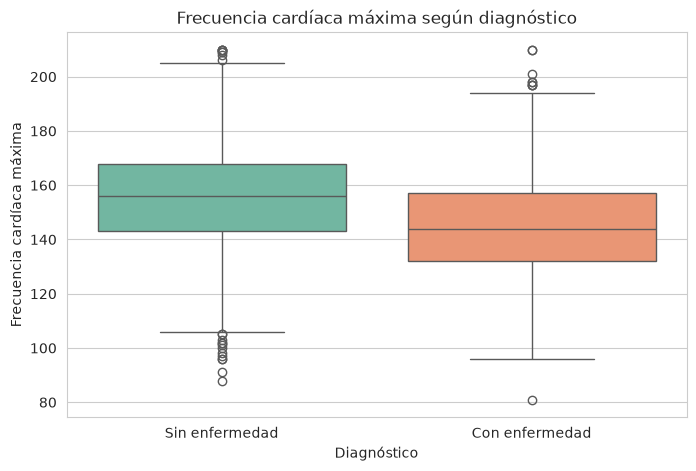

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="num",
    y="thalach",
    hue="num",
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Sin enfermedad", "Con enfermedad"])
plt.xlabel("Diagnóstico")
plt.ylabel("Frecuencia cardíaca máxima")
plt.title("Frecuencia cardíaca máxima según diagnóstico")
plt.show()

In [34]:
tabla_exang = pd.crosstab(
    df["exang"],
    df["num"],
    normalize="index"
) * 100

tabla_exang

num,0,1
exang,,
0.0,64.736537,35.263463
1.0,31.241915,68.758085


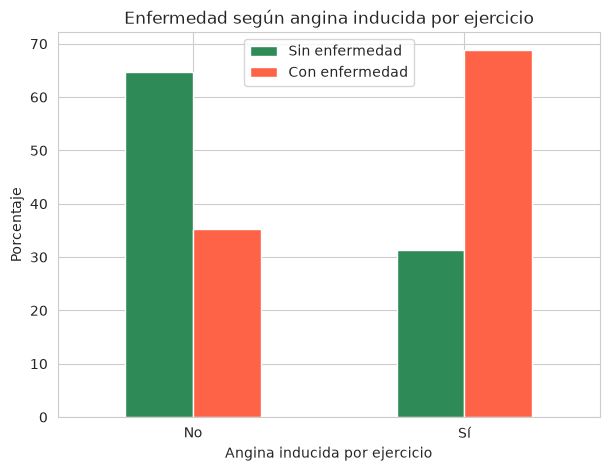

In [35]:
tabla_exang.plot(
    kind="bar",
    figsize=(7, 5),
    color=["seagreen", "tomato"]
)

plt.title("Enfermedad según angina inducida por ejercicio")
plt.xlabel("Angina inducida por ejercicio")
plt.ylabel("Porcentaje")
plt.legend(["Sin enfermedad", "Con enfermedad"])
plt.xticks([0, 1], ["No", "Sí"], rotation=0)
plt.show()

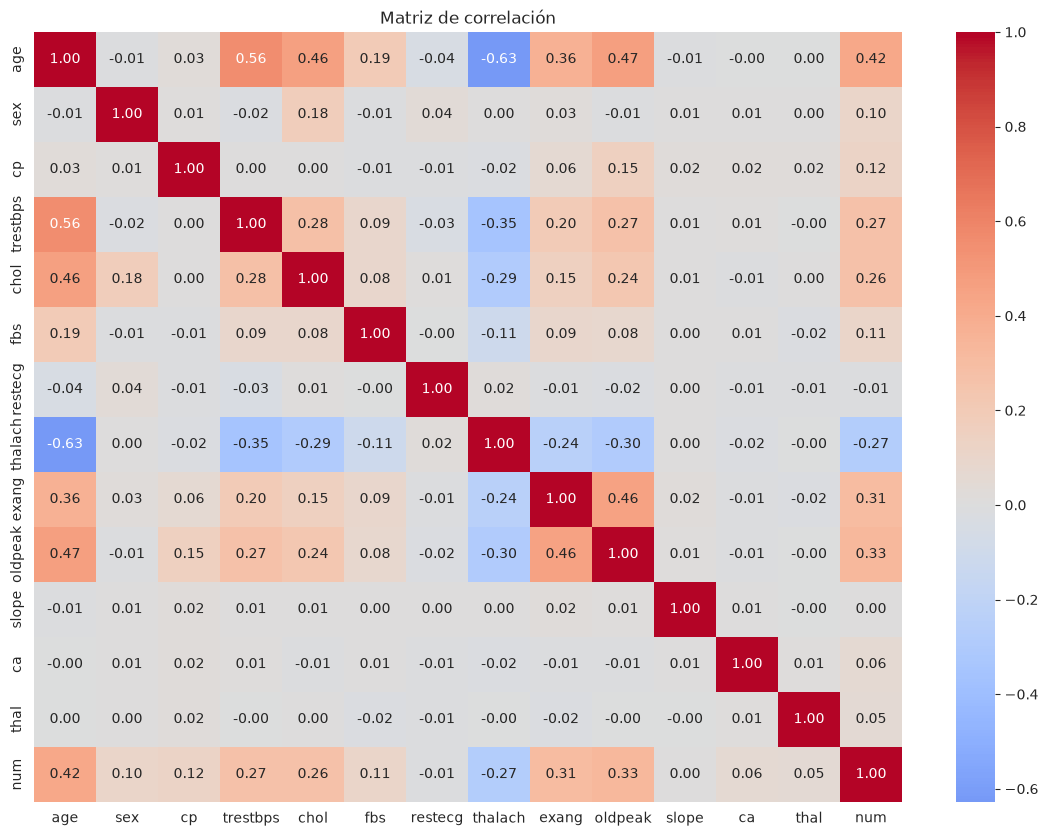

In [36]:
plt.figure(figsize=(14, 10))

correlacion = df.corr(numeric_only=True)

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

In [37]:
correlacion_diagnostico = (
    df.corr(numeric_only=True)["num"]
    .sort_values(ascending=False)
)

correlacion_diagnostico

num         1.000000
age         0.422119
oldpeak     0.326490
exang       0.310795
trestbps    0.270112
chol        0.263590
cp          0.120136
fbs         0.107144
sex         0.104795
ca          0.058424
thal        0.049207
slope       0.004832
restecg    -0.011269
thalach    -0.271955
Name: num, dtype: float64

In [38]:
X = df.drop("num", axis=1)
y = df["num"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (5000, 13)
Variable objetivo: (5000,)


In [39]:
columnas_categoricas = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

X_preprocesado = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True,
    dtype=int
)

X_preprocesado.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,32,107,196.0,159.0,1.8,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0
1,66,112,240.0,148.0,0.7,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,60,123,209.0,114.0,1.1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0
3,49,105,167.0,142.0,0.1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
4,49,114,261.0,188.0,0.1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,1


In [44]:
 pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 866.6 kB/s eta 0:00:000:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 6.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.0/474.0 kB 7.3 MB/s eta 0:00:0010.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 7.3 MB/s eta 0:00:00m eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


In [45]:
from sklearn.preprocessing import StandardScaler

columnas_para_escalar = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

scaler = StandardScaler()

X_preprocesado[columnas_para_escalar] = scaler.fit_transform(
    X_preprocesado[columnas_para_escalar]
)

X_preprocesado.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,-1.412735,-0.784792,-0.584320,0.443792,1.187438,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0
1,0.938067,-0.481306,0.522385,-0.126902,-0.368652,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0.523219,0.186365,-0.257339,-1.890864,0.197199,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0
3,-0.237334,-0.906187,-1.313739,-0.438189,-1.217428,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
4,-0.237334,-0.359911,1.050585,1.948348,-1.217428,1,1,0,0,0,0,0,1,0,1,0,0,0,0,1


In [46]:
df.to_csv(
    "heart_disease_limpio.csv",
    index=False
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [47]:
df_preprocesado = X_preprocesado.copy()
df_preprocesado["num"] = y.values

df_preprocesado.to_csv(
    "heart_disease_preprocesado.csv",
    index=False
)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_preprocesado,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (4000, 20)
Datos de prueba: (1000, 20)
